# MLOps Group Project: NER Fine-tuning

This notebook completes the Named Entity Recognition (NER) fine-tuning workflow for the `mlops-group-project`.

We use the Hugging Face `open-ner-english` dataset and fine-tune `dslim/bert-base-NER` for token classification.


In [1]:
!pip install -q transformers torch accelerate datasets wandb huggingface_hub scikit-learn seaborn matplotlib seqeval evaluate python-dotenv



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 96.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-

In [2]:
!pip install -q evaluate

In [3]:

## **Step 1 — Load credentials from Kaggle Secrets**
import os
from kaggle_secrets import UserSecretsClient

secrets = UserSecretsClient()
os.environ["WANDB_API_KEY"] = secrets.get_secret("WANDB_API_KEY")
os.environ["HF_TOKEN"]      = secrets.get_secret("HF_TOKEN")

print("Secrets loaded.")


Secrets loaded.


In [4]:
# from dotenv import load_dotenv
# load_dotenv()
import os
import random
import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    TrainingArguments,
    Trainer,
    set_seed
)
from sklearn.metrics import classification_report, confusion_matrix
import wandb
import evaluate

sns.set(style='ticks', font_scale=1.2)

SEED = int(os.getenv('SEED', '42'))
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

print(f'Using device: {device}')

WANDB_PROJECT = os.getenv('WANDB_PROJECT', 'mlops-group-project')
WANDB_RUN_NAME = os.getenv('WANDB_RUN_NAME', 'ner-fine-tune-run')
HF_REPO = os.getenv('HF_REPO', 'anuragvishwakarma02/mlops-group23-ner')


MODEL_NAME = os.getenv('MODEL_NAME', 'dslim/bert-base-NER')
MAX_LENGTH = int(os.getenv('MAX_LENGTH', '256'))
OUTPUT_DIR = os.getenv('OUTPUT_DIR', './ner_results')
LOCAL_MODEL_DIR = os.getenv('LOCAL_MODEL_DIR', './dslim-bert-base-NER-finetuned-openner')
ENABLE_WANDB = True

HF_TOKEN = os.getenv('HF_TOKEN')
    

Using device: cuda


## 1. Dataset load and sanity checks

Load the English NER dataset and inspect its structure before tokenizing.


In [5]:
import os
import pickle

pickle_path = os.getenv('DATASET_PICKLE_PATH', './open_ner_english_dataset.pkl')
try:
    if os.path.exists(pickle_path):
        with open(pickle_path, 'rb') as f:
            dataset = pickle.load(f)
        print('Loaded dataset from pickle:', pickle_path)
    else:
        dataset = load_dataset('yongsun-yoon/open-ner-english')
        with open(pickle_path, 'wb') as f:
            pickle.dump(dataset, f)
        print('Downloaded dataset from Hugging Face Hub.')
except:
    dataset=load_dataset('yongsun-yoon/open-ner-english')
    with open(pickle_path, 'wb') as f:
        pickle.dump(dataset, f)


# dataset['train'] = dataset["train"][:20000]
print(dataset)



USE_SUBSET = True
TRAIN_MAX_SAMPLES = int(os.getenv('TRAIN_MAX_SAMPLES', '20000'))
VALIDATION_MAX_SAMPLES = int(os.getenv('VALIDATION_MAX_SAMPLES', '4000'))

if USE_SUBSET:
    split_limits = {
        'train': TRAIN_MAX_SAMPLES,
        'validation': VALIDATION_MAX_SAMPLES,
    }

    for split_name, max_samples in split_limits.items():
        if split_name in dataset and max_samples > 0:
            n = min(max_samples, len(dataset[split_name]))
            dataset[split_name] = dataset[split_name].shuffle(seed=SEED).select(range(n))
            print(f'Subset applied -> {split_name}: {n} rows')


#SUBSET OF DATA
print(dataset)
print('---')
print('Train features:')
print(dataset['train'].features)
print('---')
print('Sample train item:')
# print(dataset['train'][0])



README.md:   0%|          | 0.00/553 [00:00<?, ?B/s]

data/train-00000-of-00001-30ecad5ed62b14(…):   0%|          | 0.00/32.7M [00:00<?, ?B/s]

data/validation-00000-of-00001-571aa6faa(…):   0%|          | 0.00/8.22M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/36711 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/9178 [00:00<?, ? examples/s]

Downloaded dataset from Hugging Face Hub.
DatasetDict({
    train: Dataset({
        features: ['text', 'entities'],
        num_rows: 36711
    })
    validation: Dataset({
        features: ['text', 'entities'],
        num_rows: 9178
    })
})
Subset applied -> train: 20000 rows
Subset applied -> validation: 4000 rows
DatasetDict({
    train: Dataset({
        features: ['text', 'entities'],
        num_rows: 20000
    })
    validation: Dataset({
        features: ['text', 'entities'],
        num_rows: 4000
    })
})
---
Train features:
{'text': Value('string'), 'entities': List({'entity_mentions': List(Value('string')), 'entity_type': Value('string')})}
---
Sample train item:


In [6]:
import re
import pickle

# Precompile patterns once to avoid recompiling them for every row.
FRONT_MATTER_RE = re.compile(r'^---[\s\S]*?---\s*')
CITATION_RE = re.compile(r"\[@[^\]]+\]")
SECTION_TAG_RE = re.compile(r"\{#section[^}]*\}")
LATEX_CMD_RE = re.compile(r"\\\\[A-Za-z]+")
NON_ALNUM_RE = re.compile(r"[^A-Za-z0-9\s]+")
MULTISPACE_RE = re.compile(r"\s+")

def strip_special_chars(text):
    if text is None:
        return ''

    # Normalize line breaks and non-breaking spaces to regular spaces.
    text = str(text).replace('\r\n', ' ').replace('\n', ' ').replace('\r', ' ').replace('\xa0', ' ')

    # Remove YAML header blocks at document start.
    text = FRONT_MATTER_RE.sub(' ', text)
    # Remove citation markers like [@ref].
    text = CITATION_RE.sub(' ', text)
    # Remove markdown section anchors like {#section ...}.
    text = SECTION_TAG_RE.sub(' ', text)
    # Remove LaTeX-style commands like \alpha or \Mpc.
    text = LATEX_CMD_RE.sub(' ', text)
    # Keep only letters, digits, and whitespace.
    text = NON_ALNUM_RE.sub(' ', text)
    # Normalize repeated whitespace and trim edges.
    text = MULTISPACE_RE.sub(' ', text).strip()

    text = text.strip().lower()  # convert to lowercase for better consistency in NER
    return text

def clean_entities_for_ner(entities):
    cleaned_entities = []
    if not isinstance(entities, list):
        return cleaned_entities

    for entity in entities:
        if not isinstance(entity, dict):
            continue

        entity_type = entity.get('entity_type', entity.get('type', entity.get('label')))
        mentions = entity.get('entity_mentions', [])

        if isinstance(mentions, list):
            cleaned_mentions = []
            for m in mentions:
                cm = strip_special_chars(m)
                if cm:
                    cleaned_mentions.append(cm)
            if cleaned_mentions and entity_type is not None:
                cleaned_entities.append({
                    'entity_mentions': cleaned_mentions,
                    'entity_type': entity_type,
                })
        else:
            # Keep non-mention schema as-is when we cannot normalize safely.
            cleaned_entities.append(entity)

    return cleaned_entities

def clean_example(example):
    original = example.get('text', '')
    example['raw_text'] = original
    example['text'] = strip_special_chars(original)
    example['entities'] = clean_entities_for_ner(example.get('entities', []))
    return example

dataset = dataset.map(clean_example)

cleaned_pickle_path = os.getenv('CLEANED_DATASET_PICKLE_PATH', './open_ner_english_cleaned.pkl')
with open(cleaned_pickle_path, 'wb') as f:
    pickle.dump(dataset, f)

print('Saved cleaned dataset pickle:', cleaned_pickle_path)
print('Cleaned sample text preview:')
print(dataset['train'][0]['text'][:500])
print('Sample cleaned entities:')
print(dataset['train'][0]['entities'][:2])

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Saved cleaned dataset pickle: ./open_ner_english_cleaned.pkl
Cleaned sample text preview:
friday april 29 2011 land of misfit gadgets what to do the launch of the ipad2 marked the biggest event in recommerce history after receiving a record 13k ipads gazelle a site only known for only taking used gadgets has made the first move to resale opening www gazelleipads com a first in the company s history the move brings up a trendy topic of recommerce cashing in and also getting paid for it of all the segments i have done in the past talkin recommerce on both the nate berkus show and cbs t
Sample cleaned entities:
[{'entity_mentions': ['www gazelleipads com'], 'entity_type': 'URL'}, {'entity_mentions': ['friday april 29 2011'], 'entity_type': 'DATE'}]


In [7]:
# print(dataset['train'][:5])

## 2. Label schema and split selection

Infer token and label columns, build label mappings, and choose the evaluation split.

In [8]:
import os
import re
from collections import Counter

def build_tokens_with_spans(text):
    tokens = []
    spans = []
    for m in re.finditer(r"\S+", text):
        tokens.append(m.group(0))
        spans.append((m.start(), m.end()))
    return tokens, spans

def find_all_occurrences(text, phrase):
    if not phrase:
        return []
    matches = []
    for m in re.finditer(re.escape(phrase), text):
        matches.append((m.start(), m.end()))
    return matches

def normalize_label(label):
    if label is None:
        return None
    normalized = str(label).strip().upper().replace(' ', '_')
    normalized = re.sub(r'[^A-Z0-9_\-]', '_', normalized)
    normalized = re.sub(r'_+', '_', normalized).strip('_')
    if not normalized:
        return None
    return normalized

def split_bio_tag(tag):
    if not isinstance(tag, str) or tag == 'O':
        return None, None
    if '-' not in tag:
        return None, None
    prefix, entity_type = tag.split('-', 1)
    if prefix not in {'B', 'I'}:
        return None, None
    if not entity_type:
        return None, None
    return prefix, entity_type

def get_entity_spans(entity, text):
    """Support both schemas:
    1) {'start': int, 'end': int, 'label'/'type': str}
    2) {'entity_mentions': [str, ...], 'entity_type': str}
    """
    spans = []
    if not isinstance(entity, dict):
        return spans

    # Schema 1: explicit character spans
    start = entity.get('start', entity.get('start_offset', entity.get('begin_offset')))
    end = entity.get('end', entity.get('end_offset', entity.get('stop_offset')))
    label = entity.get('label', entity.get('type', entity.get('entity', entity.get('tag'))))

    if start is not None and end is not None and label is not None:
        try:
            s = int(start)
            e = int(end)
            norm_label = normalize_label(label)
            if s < e and norm_label is not None:
                spans.append((s, e, norm_label))
        except Exception:
            pass

    # Schema 2: mention strings + entity type
    mentions = entity.get('entity_mentions', [])
    entity_type = normalize_label(entity.get('entity_type', label))
    if isinstance(mentions, list) and entity_type is not None:
        for mention in mentions:
            if not isinstance(mention, str):
                continue
            for s, e in find_all_occurrences(text, mention):
                spans.append((s, e, entity_type))

    return spans

def convert_text_entities_to_tokens_tags(example):
    text = example.get('text', '')
    entities = example.get('entities', [])

    tokens, token_spans = build_tokens_with_spans(text)
    tags = ['O'] * len(tokens)

    all_spans = []
    for entity in entities:
        all_spans.extend(get_entity_spans(entity, text))

    # Apply BIO labels based on character-span overlap.
    for start, end, label in all_spans:
        matched_token_indices = []
        for i, (ts, te) in enumerate(token_spans):
            if te > start and ts < end:
                matched_token_indices.append(i)

        if not matched_token_indices:
            continue

        # Avoid overwriting already-labeled tokens where possible.
        first = matched_token_indices[0]
        if tags[first] == 'O':
            tags[first] = f'B-{label}'
        for idx in matched_token_indices[1:]:
            if tags[idx] == 'O':
                tags[idx] = f'I-{label}'

    example['tokens'] = tokens
    example['ner_str_tags'] = tags
    return example

def collapse_rare_entity_types(example, keep_types, rare_entity_policy='O'):
    collapsed = []
    for tag in example['ner_str_tags']:
        if tag == 'O':
            collapsed.append('O')
            continue

        prefix, entity_type = split_bio_tag(tag)
        if prefix is None:
            collapsed.append('O')
            continue

        if entity_type in keep_types:
            collapsed.append(tag)
        elif rare_entity_policy == 'MISC':
            collapsed.append(f'{prefix}-MISC')
        else:
            collapsed.append('O')

    example['ner_str_tags'] = collapsed
    return example

# If dataset already has token-level labels, keep as-is. Otherwise convert from text+entities.
if 'tokens' not in dataset['train'].column_names or ('ner_tags' not in dataset['train'].column_names and 'tags' not in dataset['train'].column_names):
    dataset = dataset.map(convert_text_entities_to_tokens_tags)

    # Limit entity-type cardinality to control model head size and GPU memory.
    MAX_ENTITY_TYPES = int(os.getenv('MAX_ENTITY_TYPES', '200'))
    RARE_ENTITY_POLICY = os.getenv('RARE_ENTITY_POLICY', 'O').upper()  # 'O' or 'MISC'

    type_counter = Counter()
    for split_name in dataset.keys():
        for row in dataset[split_name]['ner_str_tags']:
            for tag in row:
                _, entity_type = split_bio_tag(tag)
                if entity_type is not None:
                    type_counter[entity_type] += 1

    if len(type_counter) > MAX_ENTITY_TYPES:
        keep_types = {entity_type for entity_type, _ in type_counter.most_common(MAX_ENTITY_TYPES)}
        dataset = dataset.map(lambda ex: collapse_rare_entity_types(ex, keep_types, RARE_ENTITY_POLICY))
        print(
            f'Collapsed rare entity types: kept top {MAX_ENTITY_TYPES} of {len(type_counter)} '
            f'(policy={RARE_ENTITY_POLICY}).'
        )

    # Build one stable label mapping across all splits.
    unique_tag_set = {'O'}
    for split_name in dataset.keys():
        for row in dataset[split_name]['ner_str_tags']:
            unique_tag_set.update(row)

    ordered_tags = ['O'] + sorted([t for t in unique_tag_set if t != 'O'])
    str2id = {tag: i for i, tag in enumerate(ordered_tags)}

    def str_tags_to_ids(example):
        example['ner_tags'] = [str2id[t] for t in example['ner_str_tags']]
        return example

    dataset = dataset.map(str_tags_to_ids)
    print('Converted dataset from text/entities to tokens/ner_tags format.')
else:
    print('Dataset already contains token-level labels.')
    label_feature = dataset['train'].features['ner_tags'].feature if 'ner_tags' in dataset['train'].features else dataset['train'].features['tags'].feature
    if hasattr(label_feature, 'names') and label_feature.names is not None:
        ordered_tags = list(label_feature.names)
    else:
        unique_ids = sorted({label for split_name in dataset.keys() for row in dataset[split_name]['ner_tags'] for label in row})
        ordered_tags = [str(i) for i in unique_ids]

def detect_columns(ds_split):
    token_col = 'tokens' if 'tokens' in ds_split.column_names else 'words'
    if 'ner_tags' in ds_split.column_names:
        label_col = 'ner_tags'
    elif 'tags' in ds_split.column_names:
        label_col = 'tags'
    else:
        raise ValueError(f'Could not find a token-label column in: {ds_split.column_names}')
    return token_col, label_col

token_col, label_col = detect_columns(dataset['train'])

label_list = list(ordered_tags)
id2label = {i: label for i, label in enumerate(label_list)}
label2id = {label: i for i, label in id2label.items()}

eval_split = 'validation' if 'validation' in dataset else 'test'

print('Token column:', token_col)
print('Label column:', label_col)
print('Number of labels:', len(label_list))
print('Labels preview:', label_list[:20], '...')
print('Evaluation split:', eval_split)
print('Sample converted record:', {k: dataset['train'][0][k] for k in ['tokens', label_col] if k in dataset['train'][0]})

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Collapsed rare entity types: kept top 200 of 7782 (policy=O).


Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Converted dataset from text/entities to tokens/ner_tags format.
Token column: tokens
Label column: ner_tags
Number of labels: 401
Labels preview: ['O', 'B-ABBREVIATION', 'B-ACTION', 'B-ACTIVITY', 'B-ACTOR', 'B-AGE', 'B-AGE_GROUP', 'B-ALBUM', 'B-ANATOMICAL_ENTITY', 'B-ANATOMICAL_STRUCTURE', 'B-ANATOMY', 'B-ANIMAL', 'B-APPARATUS', 'B-APPLICATION', 'B-ATTRIBUTE', 'B-AWARD', 'B-BAND', 'B-BIOLOGICAL_ENTITY', 'B-BIOLOGICAL_PROCESS', 'B-BIOMOLECULE'] ...
Evaluation split: validation
Sample converted record: {'tokens': ['friday', 'april', '29', '2011', 'land', 'of', 'misfit', 'gadgets', 'what', 'to', 'do', 'the', 'launch', 'of', 'the', 'ipad2', 'marked', 'the', 'biggest', 'event', 'in', 'recommerce', 'history', 'after', 'receiving', 'a', 'record', '13k', 'ipads', 'gazelle', 'a', 'site', 'only', 'known', 'for', 'only', 'taking', 'used', 'gadgets', 'has', 'made', 'the', 'first', 'move', 'to', 'resale', 'opening', 'www', 'gazelleipads', 'com', 'a', 'first', 'in', 'the', 'company', 's', 'history',

## 3. Tokenization and label alignment

Convert words to subword tokens and align labels to the first token of each word (`-100` for ignored positions).

In [9]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_and_align_labels(examples):
    tokenized = tokenizer(
        examples[token_col],
        truncation=True,
        is_split_into_words=True,
        max_length=MAX_LENGTH,
    )

    aligned_labels = []
    for batch_idx in range(len(examples[token_col])):
        word_ids = tokenized.word_ids(batch_index=batch_idx)
        labels = examples[label_col][batch_idx]

        label_ids = []
        prev_word_id = None
        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)
            elif word_id != prev_word_id:
                label_ids.append(labels[word_id])
            else:
                label_ids.append(-100)
            prev_word_id = word_id

        aligned_labels.append(label_ids)

    tokenized['labels'] = aligned_labels
    return tokenized

tokenized_dataset = dataset.map(tokenize_and_align_labels, batched=True)
print(tokenized_dataset)

# Fail early if any split contains a label id outside the model range.
expected_num_labels = len(label_list)
for split_name in tokenized_dataset.keys():
    max_seen = -1
    for row in tokenized_dataset[split_name]['labels']:
        valid = [label for label in row if label != -100]
        if valid:
            max_seen = max(max_seen, max(valid))

    print(f'{split_name}: max label id = {max_seen}, expected < {expected_num_labels}')
    if max_seen >= expected_num_labels:
        raise ValueError(
            f'Out-of-range label id found in {split_name}: {max_seen} >= {expected_num_labels}. '
            'Rebuild label_list from all splits before training.'
        )

config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'entities', 'raw_text', 'tokens', 'ner_str_tags', 'ner_tags', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 20000
    })
    validation: Dataset({
        features: ['text', 'entities', 'raw_text', 'tokens', 'ner_str_tags', 'ner_tags', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 4000
    })
})
train: max label id = 400, expected < 401
validation: max label id = 400, expected < 401


## 4. Metrics, trainer, and fine-tuning

Set token-classification metrics, initialize Trainer, and run fine-tuning.

In [10]:
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)
seqeval = evaluate.load('seqeval')

# Rebuild from the global ordered tag list so every split uses the same ids.
label_list = list(ordered_tags)
num_labels = len(label_list)
id2label = {i: label for i, label in enumerate(label_list)}
label2id = {label: i for i, label in id2label.items()}

print('Using num_labels =', num_labels)
print('id2label size =', len(id2label))
print('Max train label id =', max(label for row in dataset['train'][label_col] for label in row))
print('Max eval label id =', max(label for row in dataset[eval_split][label_col] for label in row))

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=2)

    true_predictions = []
    true_labels = []

    for pred_seq, label_seq in zip(predictions, labels):
        pred_tags = []
        true_tags = []
        for pred_id, label_id in zip(pred_seq, label_seq):
            if label_id != -100:
                pred_tags.append(label_list[pred_id])
                true_tags.append(label_list[label_id])
        true_predictions.append(pred_tags)
        true_labels.append(true_tags)

    results = seqeval.compute(predictions=true_predictions, references=true_labels)
    return {
        'precision': results['overall_precision'],
        'recall': results['overall_recall'],
        'f1': results['overall_f1'],
        'accuracy': results['overall_accuracy'],
    }

Using num_labels = 401
id2label size = 401
Max train label id = 400
Max eval label id = 400


In [11]:
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
).to(device)

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    learning_rate=3e-5,
    per_device_train_batch_size=16 if device != 'cpu' else 8,
    per_device_eval_batch_size=16 if device != 'cpu' else 8,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_strategy='steps',
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    report_to=['wandb'] if ENABLE_WANDB else [],
    run_name=WANDB_RUN_NAME,
    seed=SEED,
    push_to_hub=False,
)

if ENABLE_WANDB:
    wandb.init(
        project=WANDB_PROJECT,
        name=WANDB_RUN_NAME,
        config={
            'model_name': MODEL_NAME,
            'max_length': MAX_LENGTH,
            'num_labels': num_labels,
            'epochs': training_args.num_train_epochs,
            'train_batch_size': training_args.per_device_train_batch_size,
            'eval_batch_size': training_args.per_device_eval_batch_size,
            'dataset': 'yongsun-yoon/open-ner-english',
            'task': 'token-classification',
        },
    )

trainer_kwargs = {
    'model': model,
    'args': training_args,
    'train_dataset': tokenized_dataset['train'],
    'eval_dataset': tokenized_dataset[eval_split],
    'data_collator': data_collator,
    'compute_metrics': compute_metrics,
    'processing_class': tokenizer,  # For newer transformers versions
    # 'tokenizer': tokenizer,  # For older transformers versions
}


trainer = Trainer(**trainer_kwargs)

train_result = trainer.train()
print('Training finished')
print(train_result)

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |                                                                                       
-------------------------+------------+---------------------------------------------------------------------------------------
bert.pooler.dense.bias   | UNEXPECTED |                                                                                       
bert.pooler.dense.weight | UNEXPECTED |                                                                                       
classifier.weight        | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([9, 768]) vs model:torch.Size([401, 768])
classifier.bias          | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([9]) vs model:torch.Size([401])          

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISMATCH	:ckpt weights were loaded, but they did n

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,1.592735,1.568946,0.374816,0.211888,0.270730,0.835459
2,1.434142,1.430318,0.398145,0.228714,0.290532,0.839791
3,1.314206,1.407245,0.379380,0.259988,0.308537,0.838041


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Training finished
TrainOutput(global_step=1875, training_loss=1.602012247721354, metrics={'train_runtime': 1730.7118, 'train_samples_per_second': 34.668, 'train_steps_per_second': 1.083, 'total_flos': 7867180247040000.0, 'train_loss': 1.602012247721354, 'epoch': 3.0})


## 5. Evaluation and reports

Run final evaluation, generate token-level classification report, and visualize confusion matrix.

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Evaluation results: {'eval_loss': 1.40724515914917, 'eval_precision': 0.3793802369559312, 'eval_recall': 0.25998797147521263, 'eval_f1': 0.30853676151957243, 'eval_accuracy': 0.8380413292527693, 'eval_runtime': 46.3318, 'eval_samples_per_second': 86.334, 'eval_steps_per_second': 2.698, 'epoch': 3.0}
                           precision    recall  f1-score   support

                        O     0.8892    0.9578    0.9222    509976
           B-ABBREVIATION     0.0000    0.0000    0.0000       106
                 B-ACTION     0.0000    0.0000    0.0000       177
               B-ACTIVITY     1.0000    0.0024    0.0048       419
                  B-ACTOR     0.0000    0.0000    0.0000        17
                    B-AGE     0.0000    0.0000    0.0000        84
              B-AGE_GROUP     0.0000    0.0000    0.0000        46
                  B-ALBUM     0.0000    0.0000    0.0000        64
      B-ANATOMICAL_ENTITY     0.0000    0.0000    0.0000        13
   B-ANATOMICAL_STRUCTURE   

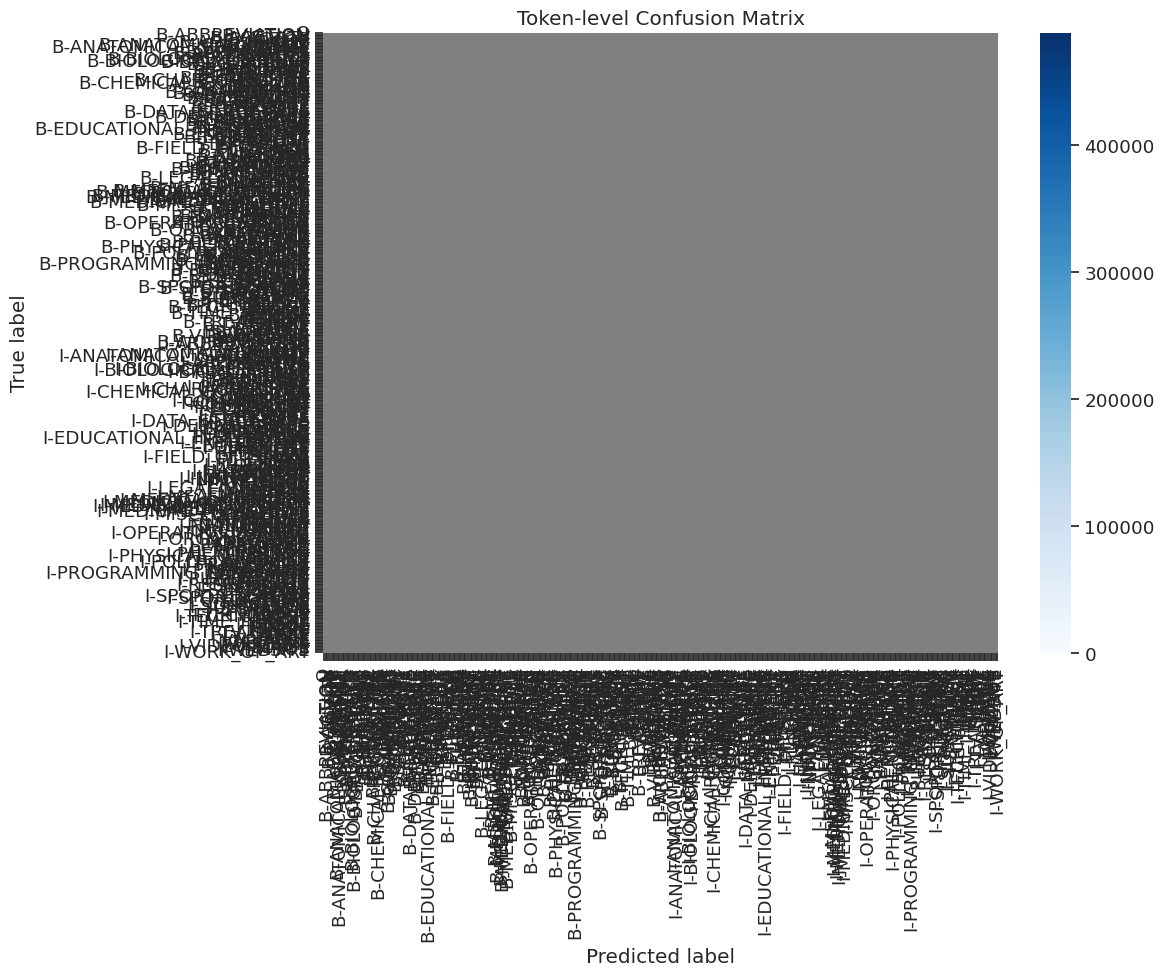

In [12]:
eval_results = trainer.evaluate(tokenized_dataset[eval_split])
print('Evaluation results:', eval_results)

pred_output = trainer.predict(tokenized_dataset[eval_split])
pred_ids = np.argmax(pred_output.predictions, axis=2)
true_ids = pred_output.label_ids

flat_true = []
flat_pred = []
for pred_seq, true_seq in zip(pred_ids, true_ids):
    for p, t in zip(pred_seq, true_seq):
        if t != -100:
            flat_true.append(t)
            flat_pred.append(p)

target_names = [id2label[i] for i in range(len(label_list))]
report = classification_report(
    flat_true,
    flat_pred,
    labels=list(range(len(label_list))),
    target_names=target_names,
    zero_division=0,
    digits=4,
    output_dict=False,
)
print(report)

cm = confusion_matrix(flat_true, flat_pred, labels=list(range(len(label_list))))
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names,
    linewidths=0.2,
    linecolor='gray',
)
plt.title('Token-level Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

if ENABLE_WANDB:
    wandb.log({f'final/{k}': v for k, v in eval_results.items() if isinstance(v, (int, float))})

## 6. Save model and optional push to Hugging Face Hub

Save locally first, then push only when `HF_TOKEN` is available in environment variables.

In [13]:
trainer.save_model(LOCAL_MODEL_DIR)
tokenizer.save_pretrained(LOCAL_MODEL_DIR)
print('Saved model/tokenizer to:', LOCAL_MODEL_DIR)

if HF_TOKEN:
    trainer.model.push_to_hub(HF_REPO, token=HF_TOKEN)
    tokenizer.push_to_hub(HF_REPO, token=HF_TOKEN)
    hf_url = f'https://huggingface.co/{HF_REPO}'
    print('Pushed model to:', hf_url)
    if ENABLE_WANDB and wandb.run is not None:
        wandb.run.summary['huggingface_model'] = hf_url
else:
    print('HF_TOKEN is missing, skipping push_to_hub.')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model/tokenizer to: ./dslim-bert-base-NER-finetuned-openner


README.md: 0.00B [00:00, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


Pushed model to: https://huggingface.co/anuragvishwakarma02/mlops-group23-ner


In [14]:
raw_eval = dataset[eval_split]
pred_output = trainer.predict(tokenized_dataset[eval_split])
pred_ids = np.argmax(pred_output.predictions, axis=2)
true_ids = pred_output.label_ids

def build_word_level_triplets(example_tokens, tokenized_inputs, pred_seq, true_seq):
    word_ids = tokenized_inputs.word_ids()
    triplets = []
    prev_word = None
    for pos, word_id in enumerate(word_ids):
        if word_id is None or word_id == prev_word:
            prev_word = word_id
            continue
        true_label_id = true_seq[pos]
        pred_label_id = pred_seq[pos]
        if true_label_id != -100 and word_id < len(example_tokens):
            triplets.append(
                (
                    example_tokens[word_id],
                    label_list[true_label_id],
                    label_list[pred_label_id],
                )
            )
        prev_word = word_id
    return triplets

sample_n = min(5, len(raw_eval))
for i in range(sample_n):
    tokens = raw_eval[i][token_col]
    tok_inputs = tokenizer(tokens, truncation=True, is_split_into_words=True, max_length=MAX_LENGTH)
    triplets = build_word_level_triplets(tokens, tok_inputs, pred_ids[i], true_ids[i])
    print(f'\nExample {i + 1}')
    print('-' * 50)
    for token, true_tag, pred_tag in triplets[:40]:
        status = 'OK' if true_tag == pred_tag else 'ERR'
        print(f'{token:16s} true={true_tag:10s} pred={pred_tag:10s} {status}')

if ENABLE_WANDB and wandb.run is not None:
    wandb.finish()
    print('W&B run finished.')

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
wandb: updating run metadata



Example 1
--------------------------------------------------
500              true=O          pred=O          OK
payday           true=O          pred=O          OK
loan             true=O          pred=O          OK
in               true=O          pred=O          OK
gretna           true=B-LOCATION pred=B-LOCATION OK
louisiana        true=B-LOCATION pred=B-LOCATION OK
gretna           true=B-LOCATION pred=B-LOCATION OK
500              true=O          pred=O          OK
payday           true=O          pred=O          OK
loan             true=O          pred=O          OK
short            true=O          pred=O          OK
term             true=O          pred=O          OK
loan             true=O          pred=O          OK
or               true=O          pred=O          OK
payday           true=O          pred=O          OK
loan             true=O          pred=O          OK
interest         true=O          pred=O          OK
rates            true=O          pred=O          OK
ar

wandb: 
wandb: Run history:
wandb:           eval/accuracy ▁█▅▅
wandb:                 eval/f1 ▁▅██
wandb:               eval/loss █▂▁▁
wandb:          eval/precision ▁█▂▂
wandb:             eval/recall ▁▃██
wandb:            eval/runtime █▂▁▆
wandb: eval/samples_per_second ▁▇█▃
wandb:   eval/steps_per_second ▁▇█▃
wandb:             final/epoch ▁
wandb:     final/eval_accuracy ▁
wandb:                     +20 ...
wandb: 
wandb: Run summary:
wandb:           eval/accuracy 0.83804
wandb:                 eval/f1 0.30854
wandb:               eval/loss 1.40725
wandb:          eval/precision 0.37938
wandb:             eval/recall 0.25999
wandb:            eval/runtime 46.3318
wandb: eval/samples_per_second 86.334
wandb:   eval/steps_per_second 2.698
wandb:             final/epoch 3
wandb:     final/eval_accuracy 0.83804
wandb:                     +26 ...
wandb: 
wandb: 🚀 View run ner-fine-tune-run at: https://wandb.ai/g25ait2017-prom-iit-rajasthan/mlops-group-project/runs/mhts5rw5
wandb: ⭐️ 

W&B run finished.


In [15]:

custom_sentences = [
    'Satya Nadella visited London to meet Microsoft teams.',
    'Barack Obama was born in Hawaii and served as U.S. President.',
    'Google announced a new AI model in California.',
]

# Reuse in-memory model/tokenizer when available; otherwise load from saved directory
try:
    infer_tokenizer = tokenizer
except NameError:
    infer_tokenizer = AutoTokenizer.from_pretrained(LOCAL_MODEL_DIR)

try:
    infer_model = model
except NameError:
    infer_model = AutoModelForTokenClassification.from_pretrained(LOCAL_MODEL_DIR).to(device)

infer_model.eval()

def predict_ner_tags(sentence, tokenizer_obj, model_obj):
    words = sentence.split()
    encoded = tokenizer_obj(
        words,
        is_split_into_words=True,
        return_tensors='pt',
        truncation=True,
        max_length=MAX_LENGTH,
    )
    encoded = {k: v.to(device) for k, v in encoded.items()}

    with torch.no_grad():
        outputs = model_obj(**encoded)
        pred_ids = torch.argmax(outputs.logits, dim=-1)[0].detach().cpu().tolist()

    word_ids = tokenizer_obj(
        words,
        is_split_into_words=True,
        truncation=True,
        max_length=MAX_LENGTH,
    ).word_ids()

    results = []
    prev_word_id = None
    for token_pos, word_id in enumerate(word_ids):
        if word_id is None or word_id == prev_word_id:
            prev_word_id = word_id
            continue
        label_id = pred_ids[token_pos]
        token = words[word_id]
        label = id2label[label_id] if label_id in id2label else str(label_id)
        results.append((token, label))
        prev_word_id = word_id

    return results

for idx, text in enumerate(custom_sentences, start=1):
    print(f'\nSentence {idx}: {text}')
    tagged_tokens = predict_ner_tags(text, infer_tokenizer, infer_model)
    print('Token-level tags:')
    for tok, tag in tagged_tokens:
        print(f'  {tok:15s} -> {tag}')

    entities = [(tok, tag) for tok, tag in tagged_tokens if tag != 'O']
    if entities:
        print('Named entities:')
        for tok, tag in entities:
            print(f'  {tok} ({tag})')
    else:
        print('Named entities: none detected')


Sentence 1: Satya Nadella visited London to meet Microsoft teams.
Token-level tags:
  Satya           -> B-PERSON
  Nadella         -> I-PERSON
  visited         -> O
  London          -> B-LOCATION
  to              -> O
  meet            -> O
  Microsoft       -> B-ORGANIZATION
  teams.          -> O
Named entities:
  Satya (B-PERSON)
  Nadella (I-PERSON)
  London (B-LOCATION)
  Microsoft (B-ORGANIZATION)

Sentence 2: Barack Obama was born in Hawaii and served as U.S. President.
Token-level tags:
  Barack          -> B-PERSON
  Obama           -> I-PERSON
  was             -> O
  born            -> O
  in              -> O
  Hawaii          -> B-LOCATION
  and             -> O
  served          -> O
  as              -> O
  U.S.            -> B-LOCATION
  President.      -> O
Named entities:
  Barack (B-PERSON)
  Obama (I-PERSON)
  Hawaii (B-LOCATION)
  U.S. (B-LOCATION)

Sentence 3: Google announced a new AI model in California.
Token-level tags:
  Google          -> B-ORGANIZATION